In [7]:
import pandas as pd

In [13]:
df = pd.read_csv('/Users/shelbylayne/Desktop/work/classes/GPGN268/Final-Project/final_marsquakes_data_frame.csv')
df.head()

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio
0,S1222a,37.01,2190.992,2022-05-04T23:23:07.710516Z,2022-05-04T23:27:34.0Z,2022-05-04T23:27:45.192771Z,1.042032
1,S1133c,30.19,1787.248,2022-02-03T08:04:36.469259Z,2022-02-03T08:08:11.7Z,2022-02-03T08:08:24.753506Z,1.060649
2,S1102a,73.31,4339.952,2022-01-02T04:27:10.093677Z,2022-01-02T04:35:19.3Z,2022-01-02T04:35:28.844688Z,1.019511
3,S1094b,59.65,3531.280,2021-12-24T22:38:02.749173Z,2021-12-24T22:44:48.7Z,2021-12-24T22:45:08.063325Z,1.047699
4,S1048d,30.19,1787.248,2021-11-07T22:00:15.254098Z,2021-11-07T22:03:42.7Z,2021-11-07T22:04:04.40886Z,1.104648


In [17]:
len(df)

175

In [20]:
type('t0')

str

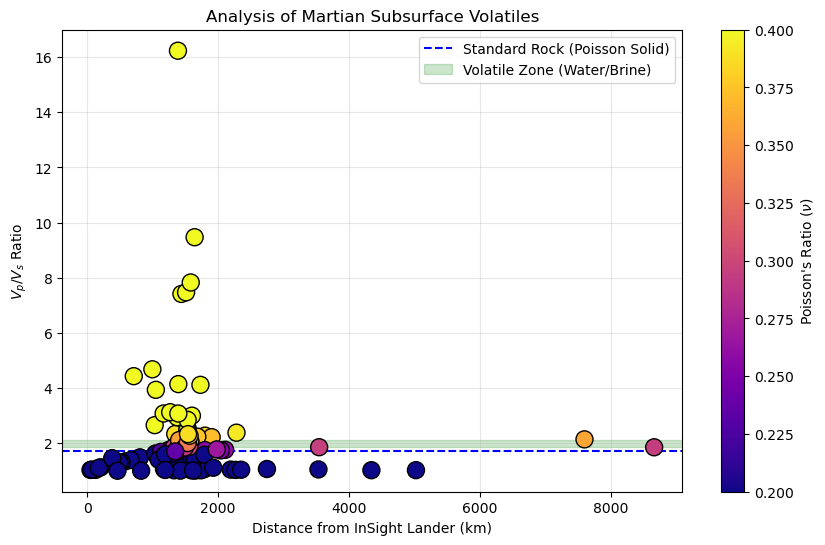

    Event_ID  Corrected_VpVs  poisson_ratio
0     S1222a        1.042032      -5.325374
1     S1133c        1.060649      -3.500766
2     S1102a        1.019511     -12.189783
3     S1094b        1.047699      -4.619145
4     S1048d        1.104648      -1.770170
..       ...             ...            ...
170   S0185b        1.012876     -18.791280
171   S0185a        1.854575       0.295036
172   S0183a        1.063935      -3.289064
173   S0128a        1.001279    -194.867101
174   S0105a        1.110192      -1.650297

[175 rows x 3 columns]


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Fix timestamps
# Convert strings to actual time objects to get accurate travel times
df['t0'] = pd.to_datetime(df['t0'])
df['tp'] = pd.to_datetime(df['tp'])
df['ts'] = pd.to_datetime(df['ts'])

# Calculate travel times in seconds
df['p_travel_time'] = (df['tp'] - df['t0']).dt.total_seconds()
df['s_travel_time'] = (df['ts'] - df['t0']).dt.total_seconds()

# Vp/Vs = S_travel / P_travel
df['VpVs'] = df['s_travel_time'] / df['p_travel_time']

# Poisson's equation
# nu is the Poisson Ratio. If nu > 0.3 there is likely fluid
df['poisson_ratio'] = ((df['VpVs']**2) - 2) / (2 * (df['VpVs']**2 - 1))

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(df['Distance_KM'], df['VpVs'], 
            c=df['poisson_ratio'], cmap='plasma', vmin=0.2, vmax=0.4, s=150, edgecolor='black', zorder=3)

# Add lines indicating volatile zone
plt.axhline(1.73, color='blue', linestyle='--', label='Standard Rock (Poisson Solid)')
plt.axhspan(1.85, 2.1, color='green', alpha=0.2, label='Volatile Zone (Water/Brine)')

plt.xlabel('Distance from InSight Lander (km)')
plt.ylabel('$V_p/V_s$ Ratio')
plt.title('Analysis of Martian Subsurface Volatiles')
plt.colorbar(label="Poisson's Ratio ($\\nu$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(df[['Event_ID', 'Corrected_VpVs', 'poisson_ratio']])

In [40]:
# Filter for fluid zone (nu > 0.3)
fluid_zone_df = df[df['poisson_ratio'] > 0.3].copy()

# 7. Print the results
print("Seismic Event Located in Potential Volatile Zone")
print(fluid_zone_df[['Event_ID', 'Distance_KM', 'VpVs', 'poisson_ratio']])


Seismic Event Located in Potential Volatile Zone
    Event_ID  Distance_KM       VpVs  poisson_ratio
7     S1000a     7594.768   2.138926       0.360140
10    S0820a     1787.248   1.972289       0.326985
21    S1106a     2279.200   2.381040       0.392919
31    S1073d     1568.800   1.939696       0.318999
35    S1060a     1592.480   1.934236       0.317603
36    S1054c     1551.040   1.927837       0.315943
37    S1054b     1497.760   1.877868       0.302089
41    S1040d     1521.440   1.887470       0.304881
43    S1039b     1797.904   2.273887       0.380112
44    S1034b     1651.680   1.974352       0.327471
47    S1026c     1864.800   2.028148       0.339403
48    S1025g     1515.520   1.919872       0.313843
50    S1019b     1799.680   2.060617       0.345971
51    S1017a     1633.920   1.962873       0.324738
67    S0933b     1598.400   1.942846       0.319797
68    S0933a     1509.600   1.903960       0.309528
76    S0899b     1568.800   1.896971       0.307581
77    S0896b   

In [41]:
len(fluid_zone_df)

60

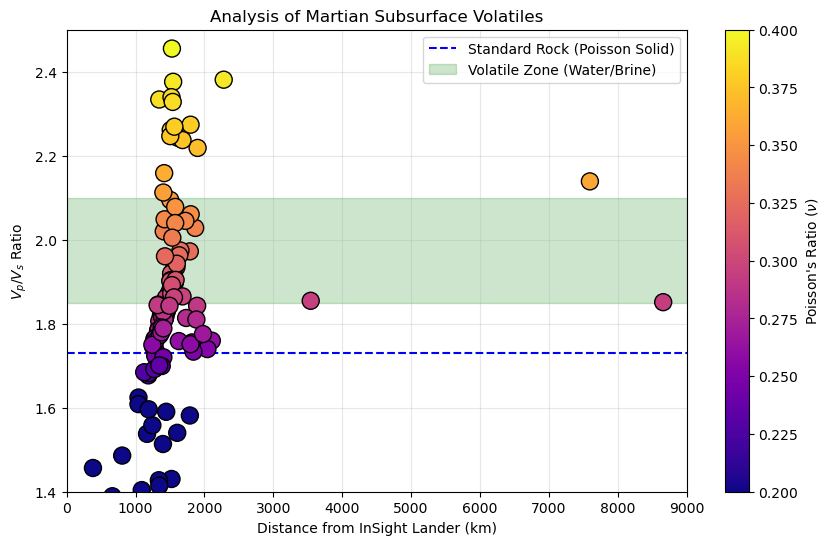

    Event_ID      VpVs  poisson_ratio
0     S1222a  1.042032      -5.325374
1     S1133c  1.060649      -3.500766
2     S1102a  1.019511     -12.189783
3     S1094b  1.047699      -4.619145
4     S1048d  1.104648      -1.770170
..       ...       ...            ...
170   S0185b  1.012876     -18.791280
171   S0185a  1.854575       0.295036
172   S0183a  1.063935      -3.289064
173   S0128a  1.001279    -194.867101
174   S0105a  1.110192      -1.650297

[175 rows x 3 columns]


In [44]:
# Convert strings to actual time objects to get accurate travel times
df['t0'] = pd.to_datetime(df['t0'])
df['tp'] = pd.to_datetime(df['tp'])
df['ts'] = pd.to_datetime(df['ts'])

# Calculate travel times in seconds
df['p_travel_time'] = (df['tp'] - df['t0']).dt.total_seconds()
df['s_travel_time'] = (df['ts'] - df['t0']).dt.total_seconds()

# Vp/Vs = S_travel / P_travel
df['VpVs'] = df['s_travel_time'] / df['p_travel_time']

# Poisson's equation
# nu is the Poisson Ratio. If nu > 0.3 there is likely fluid
df['poisson_ratio'] = ((df['VpVs']**2) - 2) / (2 * (df['VpVs']**2 - 1))

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(df['Distance_KM'], df['VpVs'], 
            c=df['poisson_ratio'], cmap='plasma', vmin=0.2, vmax=0.4, s=150, edgecolor='black', zorder=3)

# Zooming in
plt.ylim(1.4, 2.5) 
plt.xlim(0, 9000) 

# Add lines indicating volatile zone
plt.axhline(1.73, color='blue', linestyle='--', label='Standard Rock (Poisson Solid)')
plt.axhspan(1.85, 2.1, color='green', alpha=0.2, label='Volatile Zone (Water/Brine)')

plt.xlabel('Distance from InSight Lander (km)')
plt.ylabel('$V_p/V_s$ Ratio')
plt.title('Analysis of Martian Subsurface Volatiles')
plt.colorbar(label="Poisson's Ratio ($\\nu$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(df[['Event_ID', 'VpVs', 'poisson_ratio']])

Poisson's ratio measures how much a material thins when streched or bulges when compressed. High values are assosciated with fluid-saturated rocks while low values indicate stiff rocks. For instance, Earth's continental crust has an average Poisson ratio of 0.265 while Earth's oceanic crust has an average Poisson ratio of 0.30.

References:
- https://agupubs.onlinelibrary.wiley.com/doi/pdfdirect/10.1029/95JB03446?_gl=1*6ejvq6*_gcl_au*MTEzOTcxNjU5NS4xNzc3Njk2NzY3*_ga*NTI2ODIzMS4xNzc3Njk2NzY2*_ga_9C4T5P6PP6*czE3Nzc2OTY3NjckbzEkZzEkdDE3Nzc2OTY5OTgkajYwJGwwJGg4MzA5ODc1MzY.
- https://wiki.seg.org/wiki/Poisson%27s_ratio 